# LAB-P0: Introducción a los sistemas dinámicos computacionales (Julia)

- **ID de práctica:** LAB-P0-v1.0-julia
- **Capítulo del libro:** Cap. 1 — *An introduction to computational dynamic systems* (Bongers, Gómez y Torres, 2019)
- **Autores:** Dr. Antonio F. Romero Carrasco, Dra. Anelí Bongers
- **Fecha:** 2026-06-19
- **Versión:** 1.0
- **Licencia:** CC BY-SA 4.0 (este notebook) / MIT (el código de `MacroAIComp`)

Modelo de carrera de armamentos de Richardson: un sistema dinámico lineal de
dos ecuaciones que sirve de introducción a los conceptos de estado
estacionario, autovalores y estabilidad antes de abordar modelos
macroeconómicos concretos (IS-LM, Dornbusch, DGE...). Versión en Julia.


In [1]:
# En Google Colab, se instalarían los paquetes necesarios.
# En el entorno local, se asume que las dependencias ya están resueltas.
# using Pkg; Pkg.activate("."); Pkg.instantiate()


In [2]:
using Pkg
Pkg.activate("../..")

using MacroAIComp
using Plots
import Plots: mm          # Para usar unidades de margen (p.ej. top_margin=10mm)
using LinearAlgebra
using Interact   # Para el widget interactivo equivalente a ipywidgets en Python
using BenchmarkTools


  Activating project at `C:\Users\AntonioRC\Desktop\PIE`


WebIO._IJuliaInit()

## 1. Teoría

El modelo se escribe como un sistema dinámico lineal de dos variables
endógenas (ecs. 1.7-1.11 del libro):

$$
\begin{bmatrix} \Delta x_{1,t} \\ \Delta x_{2,t} \end{bmatrix}
= \underbrace{\begin{bmatrix} -\alpha & \beta \\ \gamma & -\delta \end{bmatrix}}_{A}
\begin{bmatrix} x_{1,t} \\ x_{2,t} \end{bmatrix}
+ \underbrace{\begin{bmatrix} \theta & 0 \\ 0 & \eta \end{bmatrix}}_{B}
\begin{bmatrix} z_{1,t} \\ z_{2,t} \end{bmatrix}
$$

donde $x_{1,t}$ y $x_{2,t}$ son el stock de armamento de los países 1 y 2.
El **estado estacionario** es $\bar{\mathbf{x}} = -A^{-1}B\mathbf{z}$ (ec. 1.14),
y la **estabilidad** depende de los autovalores de $A$: el sistema es
globalmente estable si $|\lambda_i + 1| < 1$ para ambos autovalores, y
presenta un **punto de silla** si solo uno de los dos cumple esa condición
(Apéndice A).


## 2. Calibración — Caso 1: estabilidad global (Tablas 1.1 y 1.2)


In [3]:
params_global = ArmsRaceParams(
    0.50,  # alpha: sensibilidad de Delta x1 a su propio nivel x1
    0.25,  # beta: reacción de Delta x1 al stock de armamento x2
    0.25,  # gamma: reacción de Delta x2 al stock de armamento x1
    0.50,  # delta: sensibilidad de Delta x2 a su propio nivel x2
    1.00,  # theta: impacto de la variable exógena z1 sobre Delta x1
    1.00   # eta: impacto de la variable exógena z2 sobre Delta x2
)
z_initial = [1.0, 1.0]

params_global


ArmsRaceParams(0.5, 0.25, 0.25, 0.5, 1.0, 1.0)

## 3. Resolución: estado estacionario y estabilidad


In [4]:
x_bar = steady_state(params_global, z_initial)
lambdas = eigenvalues(params_global)

println("Estado estacionario (x1_bar, x2_bar) = ", round.(x_bar, digits=2))
println("Autovalores (lambda1, lambda2)        = ", round.(sort(lambdas), digits=2))
println("Moduli |lambda + 1|                   = ", round.(abs.(sort(lambdas) .+ 1.0), digits=2))
println("Punto de silla                        = ", is_saddle_path(params_global))


Estado estacionario (x1_bar, x2_bar) = [4.0, 4.0]
Autovalores (lambda1, lambda2)        = [-0.75, -0.25]
Moduli |lambda + 1|                   = [0.25, 0.75]
Punto de silla                        = 

false


## 4. Verificación frente al oráculo

Comparamos contra los valores reportados en el libro y reproducidos por el
código MATLAB del Apéndice B (`referencia/m1.m`), recogidos en
`oraculo.md`: estado estacionario $(4, 4)$ y autovalores $(-0.25, -0.75)$.


In [5]:
@assert isapprox(x_bar, [4.0, 4.0]; atol=1e-6)
@assert isapprox(sort(lambdas), [-0.75, -0.25]; atol=1e-6)
println("OK: coincide con el oráculo MATLAB (Apéndice B).")


OK: coincide con el oráculo MATLAB (Apéndice B).


## 5. Análisis de shock (Sección 1.5)

Aumentamos la variable exógena $z_1$ de 1 a 2 y observamos la transición
hacia el nuevo estado estacionario.


Nuevo estado estacionario (x1_bar, x2_bar) = (

6.67, 5.33)  (esperado: 6.67, 5.33)


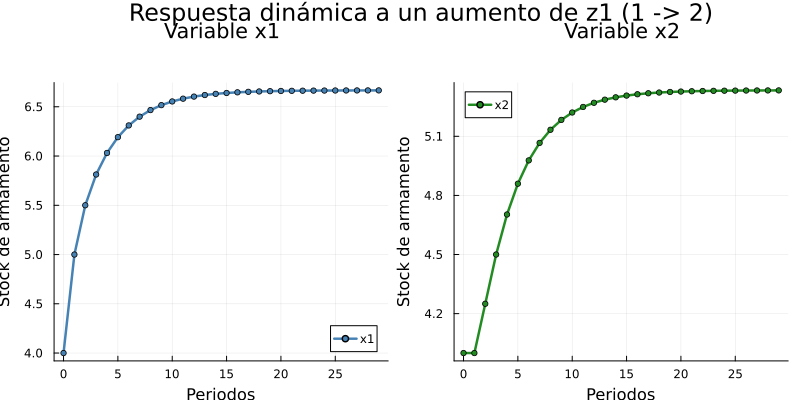

In [6]:
z_final_shock = [2.0, 1.0]
x1_path, x2_path = simulate(params_global, z_initial, z_final_shock, 30, 2)

println("Nuevo estado estacionario (x1_bar, x2_bar) = (", 
        round(x1_path[end], digits=2), ", ", round(x2_path[end], digits=2), 
        ")  (esperado: 6.67, 5.33)")

# Gráfico de respuesta a impulso — equivalente a plot_irf() del notebook Python
t = 0:29
p1 = plot(t, x1_path,
          label="x1", color=:steelblue, linewidth=2.5, marker=:circle, markersize=3,
          title="Variable x1", xlabel="Periodos", ylabel="Stock de armamento")

p2 = plot(t, x2_path,
          label="x2", color=:forestgreen, linewidth=2.5, marker=:circle, markersize=3,
          title="Variable x2", xlabel="Periodos", ylabel="Stock de armamento")

# top_margin reserva espacio para el plot_title y evita solapamiento con los títulos de subplot
plot(p1, p2, layout=(1, 2), size=(800, 400),
     plot_title="Respuesta dinámica a un aumento de z1 (1 -> 2)",
     top_margin=10mm)


## 6. Diagrama de fases (Figura B.1 del Apéndice B)


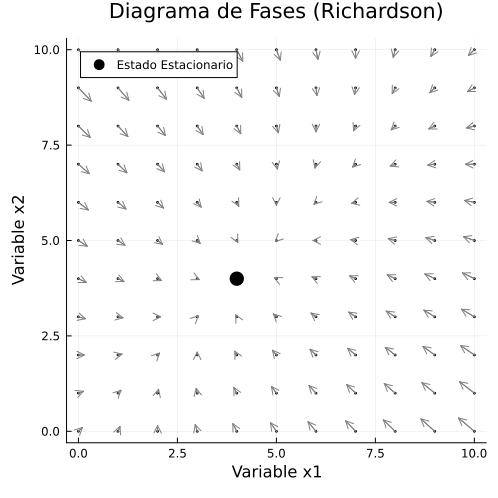

In [7]:
# En Julia, podemos generar el diagrama de fases dibujando las flechas (quiver) en una malla
a, b = coefficient_matrices(params_global)

# Crear la malla de puntos para x1 y x2
x1_vals = range(0, 10, length=11)
x2_vals = range(0, 10, length=11)

x = Float64[]
y = Float64[]
u = Float64[]
v = Float64[]

for xi in x1_vals, yi in x2_vals
    dx = a * [xi, yi] + b * z_initial
    push!(x, xi)
    push!(y, yi)
    push!(u, dx[1])
    push!(v, dx[2])
end

scale = 0.1
arrow_u = u .* scale
arrow_v = v .* scale

plt = plot(x, y, seriestype=:scatter, markersize=1, color=:gray, label="",
           title="Diagrama de Fases (Richardson)", xlabel="Variable x1", ylabel="Variable x2")
quiver!(x, y, quiver=(arrow_u, arrow_v), color=:gray)
scatter!([x_bar[1]], [x_bar[2]], color=:black, markersize=8, label="Estado Estacionario")
plot!(size=(500, 500))


## 7. Análisis de sensibilidad (Sección 1.6.1)

Aumentamos $\alpha$ de 0.50 a 0.70: el país 1 se vuelve más sensible a su
propio stock de armamento, lo que reduce el estado estacionario de ambos
países y rompe la simetría entre ellos.


In [8]:
params_sensitivity = ArmsRaceParams(0.70, 0.25, 0.25, 0.50, 1.00, 1.00)
x_bar_sensitivity = steady_state(params_sensitivity, z_initial)
lambdas_sensitivity = eigenvalues(params_sensitivity)

println("Estado estacionario (x1_bar, x2_bar) = ", round.(x_bar_sensitivity, digits=2), " (esperado: 2.61, 3.30)")
println("Autovalores                          = ", round.(sort(lambdas_sensitivity), digits=2), " (esperado: -0.87, -0.33)")
println("Punto de silla                       = ", is_saddle_path(params_sensitivity), " (esperado: false)")

@assert isapprox(x_bar_sensitivity, [2.61, 3.30]; atol=1e-2)
@assert isapprox(sort(lambdas_sensitivity), [-0.87, -0.33]; atol=1e-2)


Estado estacionario (x1_bar, x2_bar) = [2.61, 3.3] (esperado: 2.61, 3.30)
Autovalores                          = [-0.87, -0.33] (esperado: -0.87, -0.33)
Punto de silla                       = false (esperado: false)


## 8. Punto de silla (Sección 1.6.2)

Con $\beta, \gamma > \alpha, \delta$ (Tabla 1.3) el sistema tiene un
autovalor estable y otro inestable: el estado estacionario es un punto de
silla. La variable $x_1$ se asume "de salto" (forward-looking) y se
reajusta instantáneamente sobre la senda estable ante una perturbación
(ec. 1.39), mientras $x_2$ evoluciona de forma estándar.


In [ ]:
params_saddle = ArmsRaceParams(0.25, 0.50, 0.50, 0.25, 1.00, 1.00)
z_initial_saddle = [-1.0, -1.0]
z_final_saddle = [-0.5, -1.0]

println("Punto de silla = ", is_saddle_path(params_saddle), " (esperado: true)")

x1_saddle, x2_saddle = simulate_saddle_path(
    params_saddle, z_initial_saddle, z_final_saddle, 30, 2, 1
)

println("Salto instantáneo de x1 en el periodo del shock = ", round(x1_saddle[2], digits=2), " (esperado: 2.00)")
println("Nuevo estado estacionario (x1, x2) = (", 
        round(x1_saddle[end], digits=2), ", ", round(x2_saddle[end], digits=2), 
        ")  (esperado: 3.33, 2.67)")

@assert isapprox(x1_saddle[2], 2.0; atol=1e-2)
@assert isapprox([x1_saddle[end], x2_saddle[end]], [3.33, 2.67]; atol=1e-2)

# Graficar la trayectoria del punto de silla
t_axis = 0:29
p_s1 = plot(t_axis, x1_saddle,
            label="x1 (salto)", color=:purple, linewidth=2.5, marker=:circle, markersize=3,
            title="Variable x1", xlabel="Periodos", ylabel="Stock de armamento")

p_s2 = plot(t_axis, x2_saddle,
            label="x2", color=:orange, linewidth=2.5, marker=:circle, markersize=3,
            title="Variable x2", xlabel="Periodos", ylabel="Stock de armamento")

# top_margin reserva espacio para el plot_title y evita solapamiento
plot(p_s1, p_s2, layout=(1, 2), size=(800, 400),
     plot_title="Punto de silla: ajuste instantáneo de x1 ante el shock en z1",
     plot_titlefontsize=11,
     top_margin=10mm)


## 9. Widget interactivo — sensibilidad al shock de z1

Equivalente al `FloatSlider` de `ipywidgets` en Python: usa `@manipulate` de `Interact.jl`
para mover el slider de $z_1^{\text{final}}$ en tiempo real y ver la respuesta dinámica
del sistema ante distintas magnitudes de shock.


In [10]:
# Widget interactivo equivalente al FloatSlider de Python
# Mueve el slider para cambiar la magnitud del shock sobre z1
@manipulate for z1_final in -2.0:0.25:4.0
    x1_p, x2_p = simulate(params_global, z_initial, [z1_final, 1.0], 30, 2)

    t_ax = 0:29
    p_a = plot(t_ax, x1_p,
               label="x1", color=:steelblue, linewidth=2.5,
               title="Variable x1", xlabel="Periodos", ylabel="Stock de armamento")

    p_b = plot(t_ax, x2_p,
               label="x2", color=:forestgreen, linewidth=2.5,
               title="Variable x2", xlabel="Periodos", ylabel="Stock de armamento")

    # top_margin reserva espacio para el plot_title y evita solapamiento con los títulos de subplot
    plot(p_a, p_b, layout=(1, 2), size=(820, 400),
         plot_title="Shock z1: 1 -> $z1_final",
         top_margin=10mm)
end


Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Scope(Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :label), Any["z1_final"], Dict{Symbol, Any}(:className => "interact ", :style => Dict{Any, Any}(:padding => "5px 10px 0px 10px")))], Dict{Symbol, Any}(:className => "interact-flex-row-left")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :input), Any[], Dict{Symbol, Any}(:max => 25, :min => 1, :attributes => Dict{Any, Any}(:type => "range", Symbol("data-bind") => "numericValue: index, valueUpdate: 'input', event: {change: function (){this.changes(this.changes()+1)}}", "orient" => "horizontal"), :step => 1, :className => "slider slider is-fullwidth", :style => Dict{Any, Any}()))], Dict{Symbol, Any}(:className => "interact-flex-row-center")), Node{WebIO.DOM}(WebIO.DOM(:html, :div), Any[Node{WebIO.DOM}(WebIO.DOM(:html, :p), Any[], Dict{Symbol, Any}(:attributes => Dict("data-bind" => "text: formatted_val")))], Dict{Symbol, Any}(:className => "interact-flex-row-right"))], Dict{Symbol, Any}(:className => "interact-flex-row interact-widget")), Dict{String, Tuple{AbstractObservable, Union{Nothing, Bool}}}("changes" => (Observable(0), nothing), "index" => (Observable{Any}(13), nothing)), Set{String}(), nothing, Asset[Asset("js", "knockout", "C:\\Users\\AntonioRC\\.julia\\packages\\Knockout\\HReiN\\src\\..\\assets\\knockout.js"), Asset("js", "knockout_punches", "C:\\Users\\AntonioRC\\.julia\\packages\\Knockout\\HReiN\\src\\..\\assets\\knockout_punches.js"), Asset("js", nothing, "C:\\Users\\AntonioRC\\.julia\\packages\\InteractBase\\8TTmI\\src\\..\\assets\\all.js"), Asset("css", nothing, "C:\\Users\\AntonioRC\\.julia\\packages\\InteractBase\\8TTmI\\src\\..\\assets\\style.css"), Asset("css", nothing, "C:\\Users\\AntonioRC\\.julia\\packages\\Interact\\PENUy\\src\\..\\assets\\bulma_confined.min.css")], Dict{Any, Any}("changes" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"changes\"]()) ? (this.valueFromJulia[\"changes\"]=true, this.model[\"changes\"](val)) : undefined})")], "index" => Any[WebIO.JSString("(function (val){return (val!=this.model[\"index\"]()) ? (this.valueFromJulia[\"index\"]=true, this.model[\"index\"](val)) : undefined})")]), WebIO.ConnectionPool(Channel{Any}(32), Set{AbstractConnection}(), Base.GenericCondition(ReentrantLock())), WebIO.JSString[WebIO.JSString("function () {\n    var handler = (function (ko, koPunches) {\n    ko.punches.enableAll();\n    ko.bindingHandlers.numericValue = {\n        init: function(element, valueAccessor, allBindings, data, context) {\n            var stringified = ko.observable(ko.unwrap(valueAccessor()));\n            stringified.subscribe(function(value) {\n                var val = parseFloat(value);\n                if (!isNaN(val)) {\n                    valueAccessor()(val);\n                }\n            });\n            valueAccessor().subscribe(function(value) {\n                var str = JSON.stringify(value);\n                if ((str == \"0\") && ([\"-0\", \"-0.\"].indexOf(stringified()) >= 0))\n                     return;\n                 if ([\"null\", \"\"].indexOf(str) >= 0)\n                     return;\n                stringified(str);\n            });\n            ko.applyBindingsToNode(\n                element,\n                {\n                    value: stringified,\n                    valueUpdate: allBindings.get('valueUpdate'),\n                },\n                context,\n            );\n        }\n    };\n    var json_data = {\"formatted_vals\":[\"-2.0\",\"-1.75\",\"-1.5\",\"-1.25\",\"-1.0\",\"-0.75\",\"-0.5\",\"-0.25\",\"0.0\",\"0.25\",\"0.5\",\"0.75\",\"1.0\",\"1.25\",\"1.5\",\"1.75\",\"2.0\",\"2.25\",\"2.5\",\"2.75\",\"3.0\",\"3.25\",\"3.5\",\"3.75\",\"4.0\"],\"changes\":WebIO.getval({\"name\":\"changes\",\"scope\":\"3419762224667354811\",\"id\":\"3\",\"type\":\"observable\"}),\"index\":WebIO.

## 10. Buenas Prácticas Aplicadas en este Laboratorio

Observa que `steady_state()`, `eigenvalues()`, `simulate()` y
`simulate_saddle_path()` están documentadas, tienen restricciones de tipo y viven en
`src/models/ArmsRace.jl` — no en este notebook. La lógica del modelo está separada
de la visualización. Cuando hagas tu ABP, haz lo mismo: funciones reutilizables a `src/`,
el notebook solo para exponer y narrar el análisis.


## 11. Conclusión

El mismo sistema dinámico lineal puede mostrar dos comportamientos
cualitativamente distintos según el valor de sus parámetros: estabilidad
global, donde toda perturbación converge suavemente al nuevo equilibrio, o
un punto de silla, donde una variable debe "saltar" instantáneamente para
mantener la convergencia. Esta distinción —y el procedimiento para
detectarla a partir de los autovalores de $A$— es la base que reutilizaremos
en el resto de prácticas (IS-LM dinámico, Dornbusch, DGE) cuando los
sistemas dejen de ser ejemplos genéricos y representen economías reales.
Los resultados numéricos coinciden exactamente con el oráculo MATLAB del
Apéndice B, lo que valida el port a Julia.


## 6. Benchmark de Rendimiento (Fase III)
Evaluamos la velocidad de simulación de las trayectorias usando `BenchmarkTools.jl`.

In [11]:
# Benchmark simulation para un sistema 2D dinámico
A_bench = [0.5 0.2; 0.1 0.8]
x0_bench = [1.0, 1.0]
T_bench = 50

function simular_sistema(A_mat, init, T)
    n = length(init)
    x = zeros(n, T)
    x[:, 1] = init
    for t in 1:(T-1)
        x[:, t+1] = A_mat * x[:, t]
    end
    return x
end

@btime simular_sistema($A_bench, $x0_bench, $T_bench)


  1.750 μs (198 allocations: 8.58 KiB)


2×50 Matrix{Float64}:
 1.0  0.7  0.53  0.423  0.3485  0.29231  0.247573  …  0.000359584  0.00030786
 1.0  0.9  0.79  0.685  0.5903  0.50709  0.434903     0.000640339  0.00054823